In [1]:
import gzip

with gzip.open(r"D:\data\petWiki\data_raw\pageviews-20260301-000000.gz", "rt", encoding="utf-8") as f:
    for _ in range(5226, 5250):
        print(repr(f.readline()))

'"" $_natural_language 1 0\n'
'"" - 2140 0\n'
'"" Abstract_Wikipedia/Overview/sv 1 0\n'
'"" Administrators_of_Wikimedia_projects/Wikiversities 1 0\n'
'"" Batches 1 0\n'
'"" Category:Abstract_Wikipedia/tr 1 0\n'
'"" Category:Confirmed_users/uk 1 0\n'
'"" Category:Constants 1 0\n'
'"" Category:English_natural_language_generation_functions 1 0\n'
'"" Category:Introduction/hi 1 0\n'
'"" Category:Link_templates/he 1 0\n'
'"" Category:List_templates_with_deprecated_parameters 1 0\n'
'"" Category:Mandarin_-_Simplified_Han_script_language_generation_functions\u200b 1 0\n'
'"" Category:Natural_languages 1 0\n'
'"" Category:Policy/sr 1 0\n'
'"" Category:Project_concept/fr 1 0\n'
'"" Category:Shortcuts/ja 1 0\n'
'"" Category:Shortcuts/pl 1 0\n'
'"" Category:Technical_documentation/es 1 0\n'
'"" Category:Technical_documentation/id 1 0\n'
'"" Category:Templates/ko 1 0\n'
'"" Category:Templates/ur 1 0\n'
'"" Category:Translators_eng-nor 1 0\n'
'"" Category:Translators_ind-eng 1 0\n'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import os
import re

file_path = r"D:\data\petWiki\data_raw\pageviews-20260301-000000.gz"
file_name = os.path.basename(file_path)

In [6]:
import pandas as pd

df = pd.read_csv(
    r"D:\data\petWiki\data_raw\pageviews-20260301-000000.gz",
    sep=" ",
    header=None,
    names=["project", "article", "views", 'bytes'],
    compression="gzip",
    on_bad_lines='warn', 
)

df = df.dropna()


In [7]:
df.describe()

,views,bytes
count,5.535889e+06,5535889.0
mean,3.480958e+00,0.0
std,1.762822e+02,0.0
min,1.000000e+00,0.0
25%,1.000000e+00,0.0
50%,1.000000e+00,0.0
75%,2.000000e+00,0.0
max,3.016650e+05,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5535889 entries, 5226 to 5541133
Data columns (total 4 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   project  object
 1   article  object
 2   views    int64 
 3   bytes    int64 
dtypes: int64(2), object(2)
memory usage: 211.2+ MB


In [9]:
df['article'] = df['article'].fillna('-').astype(str)

df_clean = df[
    (~df['article'].str.contains(':')) & 
    (df['article'] != '-') &
    (df['views'] > 1)
].copy()

print(f"Осталось строк после чистки: {len(df_clean)}")
print(df_clean.sample(10)) # Посмотреть случайные 10 строк

Осталось строк после чистки: 1770986
        project                                            article  views  \
4476451    ja.m                                               石川優子      2   
637327       en  2014–15_UEFA_Champions_League_qualifying_phase...      2   
5135408      sh                           Mason_County,_Washington      2   
3157275  en.voy                            Hampden_(Massachusetts)      3   
1808949      en                                          Webmaster      2   
3076074    en.m                          Yellow_Line_(Namma_Metro)      2   
2255004    en.m                                           Edgeplay     12   
3763865    fr.m                                          Mehmed_VI      3   
3456406    es.m                                       Time_Bandits      2   
2766739    en.m             Prince_George_William_of_Great_Britain      3   

         bytes  
4476451      0  
637327       0  
5135408      0  
3157275      0  
1808949      0  
3076074      

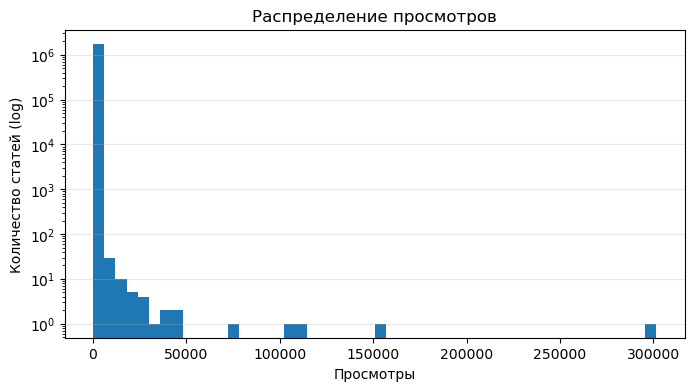

In [10]:
plt.figure(figsize=(8,4))
plt.hist(df_clean['views'], bins=50, log=True)
plt.title('Распределение просмотров')
plt.xlabel('Просмотры')
plt.ylabel('Количество статей (log)')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [11]:
df_split = df_clean['project'].str.split('.', expand = True)

In [12]:
df_clean['language'] = df_split[0]
df_clean['platform'] = df_split[1]
df_clean = df_clean.drop(['project', 'bytes'], axis=1)

In [13]:
df_clean['platform'].unique()

array([None, 'm', 'd', 'q', 'b', 'n', 's', 'v', 'voy', 'w', 'wd'],
      dtype=object)

In [14]:
platform_map = {
    'm': 'mobile',    
    'd': 'desktop',
    'b': 'wikibooks',
    'n': 'wikinews',
    'q': 'wikiquote',
    's': 'wikisource',
    'v': 'wikiversity',
    'voy': 'wikivoyage',
    'w': 'mediawiki',
    'wd': 'wikidata'
}

In [15]:
df_clean['platform'] = df_clean['platform'].map(platform_map).fillna('desktop')

In [16]:
df_clean.sort_values('views', ascending=False)

,article,views,language,platform
2003245,Ali_Khamenei,301665,en,mobile
1296925,Main_Page,156739,en,desktop
2595642,Main_Page,112787,en,mobile
3560045,Cookie_(informatique),104268,fr,desktop
690198,Ali_Khamenei,77833,en,desktop
...,...,...,...,...
3581973,Ibrahim_Maza,2,fr,desktop
1705528,Tom_Jans,2,en,desktop
3581979,"Ibrahima_Baldé_(football,_2003)",2,fr,desktop
1705526,Tom_Jaine,2,en,desktop


In [17]:
match = re.search(r'(\d{8})-(\d{6})', file_name)
if match:
    dt_str = match.group(1) + match.group(2)

    timestamp = pd.to_datetime(dt_str, format='%Y%m%d%H%M%S')

df_clean['datetime'] = timestamp

df_clean.head()

,article,views,language,platform,datetime
5231,Main_Page,9,aa,desktop,2026-03-01
5350,Ихадоу_адаҟьа,24,ab,desktop,2026-03-01
5352,"Меркель,_Ангела",2,ab,desktop,2026-03-01
5456,YouTube,3,ab,mobile,2026-03-01
5493,Ихадоу_адаҟьа,7,ab,mobile,2026-03-01


In [24]:
print(df_clean['article'].str.len().max())
df_clean.loc[df_clean['article'].str.len().idxmax(), 'article']

1516


'Royce_da_5\'9\\" 3 0\nen Royce_da_5′9″ 1 0\nen Roychester,_Pennsylvania 1 0\nen Royd_R._Sayers 1 0\nen Royd_Tolkien 1 0\nen Roydell_Williams_(running_back) 1 0\nen Royden_B._Davis 1 0\nen Royden_Rabinowitch 2 0\nen Roydon 1 0\nen Roydon_railway_station 1 0\nen Royel_Otis 11 0\nen Royer_Labs 2 0\nen Royer_oscillator 1 0\nen Royoporus 1 0\nen Royoungia 1 0\nen Royse_City,_Texas 2 0\nen Royse_City_High_School 1 0\nen Royston 1 0\nen Royston\'s_Shorts 1 0\nen Royston,_Georgia 1 0\nen Royston,_Hertfordshire 2 0\nen Royston_Cave 2 0\nen Royston_Langdon 5 0\nen Royston_Park,_South_Australia 1 0\nen Royston_Smith 1 0\nen Royston_Wright 1 0\nen Royston_to_Thornhill_line 1 0\nen Roystonea_borinquena 1 0\nen Roystonea_regia 1 0\nen Roz_Abrams 1 0\nen Roz_Chast 1 0\nen Roz_Doyle 4 0\nen Roz_Kelly 1 0\nen Roz_Payne 1 0\nen Roz_Ward 1 0\nen Roza,_Russia 1 0\nen Roza_Atamuradovna_Bazarova 2 0\nen Roza_Bal 2 0\nen Roza_Eskenazi 1 0\nen Roza_Miletić 1 0\nen Roza_Nozari 1 0\nen Roza_Robota 1 0\nen Roza

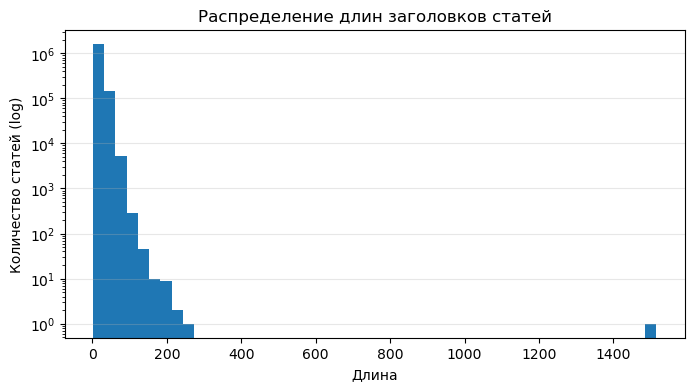

In [33]:
plt.figure(figsize=(8,4))
plt.hist(df_clean['article'].str.len(), bins=50, log=True)
plt.title('Распределение длин заголовков статей')
plt.xlabel('Длина')
plt.ylabel('Количество статей (log)')
plt.grid(axis='y', alpha=0.3)
plt.show()

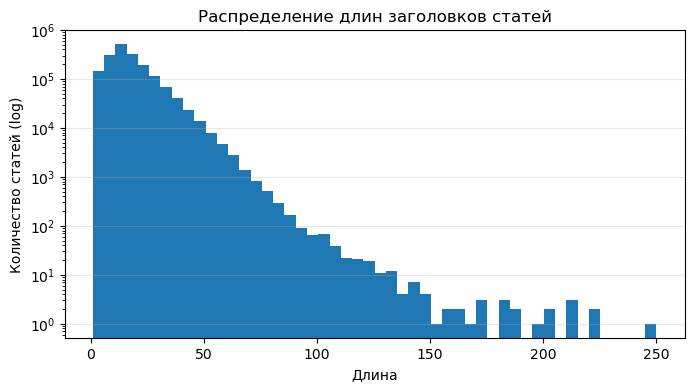

In [34]:
df_clean = df_clean[df_clean['article'].str.len() <= 250]

plt.figure(figsize=(8,4))
plt.hist(df_clean['article'].str.len(), bins=50, log=True)
plt.title('Распределение длин заголовков статей')
plt.xlabel('Длина')
plt.ylabel('Количество статей (log)')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [35]:
print(df_clean['article'].str.len().max())
df_clean.loc[df_clean['article'].str.len().idxmax(), 'article']

print(longest_article)

250
Cneoridium_dumosum_(Nuttall)_Hooker_F._Collected_March_26,_1960,_at_an_Elevation_of_about_1450_Meters_on_Cerro_Quemazón,_15_Miles_South_of_Bahía_de_Los_Angeles,_Baja_California,_México,_Apparently_for_a_Southeastward_Range_Extension_of_Some_140_Miles
